# Assignment 2 — AcnEmpathize: Prompting

**Course:** Natural Language Processing  
**Group:** 12

    Guilherme Oliveira: 202204987
    Magda Costa: 202207036

---

# Index

1. [Motivation](#motivation)
2. [Setup](#setup)
3. [Prompt Design](#prompts)
4. [Run Prompting Experiments](#run)
5. [Results and Comparison](#results)
6. [Conclusions](#conclusions)

---
# 1. Motivation <a name="motivation"></a>

### Where we are

Across notebooks 6, 7, and 8 we built a complete supervised learning story for AcnEmpathize:

| Model | Macro-F1 | Emp-F1 | Trainable Params | Time |
|---|---|---|---|---|
| LR + TF-IDF trigrams (A1) | 0.761 | 0.637 | ~5k | <1 min |
| RoBERTa-base (full FT) | 0.888 | 0.829 | ~125M | 118 min |
| RoBERTa-TAPT (full FT) | 0.891 | 0.836 | ~125M | ~180 min |
| LoRA RoBERTa-TAPT | 0.887 | 0.832 | 887k (0.71%) | 110 min |
| **LoRA RoBERTa-base** | **0.898** | **0.849** | **887k (0.71%)** | **89 min** |

Every model in this table required labelled training data. The best result (LoRA, Macro-F1=0.898) was achieved by training on 7,774 labelled posts. But what if we had **no labelled data at all?**

This is the question prompting addresses — and it is fundamentally different from everything we have done so far. Prompting is not another point on the efficiency/performance tradeoff curve. It is a **different paradigm entirely**: instead of learning from examples, we directly operationalise the annotation guidelines as a natural language instruction and ask a pre-trained language model to apply them.

---

### Why this is motivated by our own results

The annotation framework for AcnEmpathize (Lee & Parde 2024, adapted from Sharma et al. 2020) is explicit and precise. A post contains empathy if it satisfies **at least one** of:

1. **Emotional Reaction** — expresses warmth, compassion, or concern towards the seeker
2. **Interpretation** — communicates understanding of the seeker's experiences and feelings
3. **Exploration** — attempts to explore the seeker's experiences and feelings

And it is **not** empathy if it contains only:
- Advice or factual information
- Kindness or support without overt emotional understanding (*"good luck"*, *"I wish the best for you"*)
- Self-focused positivity (*"I'm so glad the cysts are gone!"*)
- Statements requiring assumptions about a different post

This framework is precise enough to be given directly to an instruction-tuned language model. The question is whether a model can apply these guidelines **without seeing a single labelled example**.

Two of our most consistent findings across A1 and A2 make this particularly interesting:

**Finding 1 — False positives are the main error type in both classical and transformer models.** Supportive and advice-heavy posts with warm tone are systematically mistaken for empathy. This is exactly the boundary the annotation guidelines draw most carefully — the distinction between kindness/support and genuine empathy. Prompting with explicit hard-negative examples targeting this boundary is theoretically the most direct way to address it.

**Finding 2 — The empathy signal is strongly lexical.** A1 showed that words like *"know"*, *"feel"*, *"sorry"*, *"relate"*, *"understand"* are the top discriminative features. An instruction-tuned LLM likely already associates these with empathy — but it may also associate *"good luck"* and *"hang in there"* with empathy, which violates the annotation framework.

---

### What we test and why

We test three prompting conditions, each motivated by the above:

**Condition 1 — Zero-shot:** The annotation guidelines only, no examples. Tests whether the LLM can apply the three-mechanism framework directly from the instruction.

**Condition 2 — Few-shot with hard negatives:** Guidelines plus 3 empathy examples and 3 non-empathy examples, where the non-empathy examples are specifically chosen to be *advice-only* and *kindness-only* posts — the exact false-positive error type identified in A1 and confirmed in A2. This condition directly targets the systematic error that all our supervised models share.

**Condition 3 — Chain-of-thought:** Same guidelines as zero-shot, but the model is asked to reason step-by-step before committing to a label: (a) what is the author doing, (b) which mechanism applies, (c) is it only advice/kindness? The JSON label appears on the last line. CoT prompting often improves boundary-case decisions by forcing explicit reasoning, and produces an interpretable trace of model logic — something supervised classifiers cannot provide.

We do **not** test a plain balanced few-shot condition, because random examples would not address the specific false-positive failure mode. Every prompting design choice is grounded in what we already know from A1 and A2.

---

### Scope and evaluation

Prompting with a large instruction model is slow. We evaluate on a **stratified sample of 200 posts** from the Split B test set (preserving the 25.5%/74.5% empathy/no-empathy ratio). This is sufficient to estimate Macro-F1 and empathy F1 reliably, and is standard practice for prompting evaluations where inference cost is high.

We use `Qwen2.5-1.5B-Instruct` (Alibaba Cloud) via **local HuggingFace Transformers inference** running on MPS (Apple Silicon). The original plan was a larger model (Mistral-7B via Groq API), but API rate limits made the 200-post evaluation impractical. Qwen2.5-1.5B-Instruct was chosen as the best locally-feasible alternative: it is instruction-tuned, follows JSON output constraints reliably, and runs in reasonable time on MPS. The tradeoff is a smaller model than originally intended — results should be interpreted with that in mind, as a 7B+ model would likely narrow the gap to supervised baselines.

---

### References
- Lee & Parde (2024). *AcnEmpathize: A Dataset for Understanding Empathy in Dermatology Conversations.* LREC-COLING.
- Sharma et al. (2020). *A Computational Approach to Understanding Empathy Expressed in Text-Based Mental Health Support.* EMNLP.
- Brown et al. (2020). *Language Models are Few-Shot Learners.* NeurIPS.
- Wei et al. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models.* NeurIPS.
- Qwen Team (2024). *Qwen2.5 Technical Report.* arXiv:2412.15115.

---
# 2. Setup <a name="setup"></a>

In [9]:
import re
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from dotenv import load_dotenv
import os
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, average_precision_score, confusion_matrix,
)

warnings.filterwarnings("ignore")

SEED      = 42
np.random.seed(SEED)

# ── Paths and constants ───────────────────────────────────────────────────────
TEXT_COL  = "text"
LABEL_COL = "combined_empathy"
CONV_COL  = "conv_id"
OUTPUT_DIR = Path("results/prompting")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── HuggingFace token (read from .env) ────────────────────────────────────────
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN", "")
if HF_TOKEN:
    import huggingface_hub
    huggingface_hub.login(token=HF_TOKEN, add_to_git_credential=False)
    print(f"Logged in to HuggingFace: {HF_TOKEN[:8]}...")
else:
    print("Warning: HF_TOKEN not set — only public/ungated models can be loaded.")

# ── Local model — no API key, no rate limits ──────────────────────────────────
# Qwen2.5-1.5B-Instruct: 1.5B, not gated, strong instruction following.
# Runs on MPS (Apple Silicon) via device_map="auto".
# To use Llama-3.2-1B-Instruct instead: accept Meta's license at
#   https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct
# then set MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

print(f"Loading {MODEL_ID}...")
_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
_model     = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=torch.bfloat16)
_pipe = pipeline(
    "text-generation",
    model=_model,
    tokenizer=_tokenizer,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
print(f"Model ready: {MODEL_ID}  |  device: {_pipe.device}")


def hf_chat(system_msg, user_msg, max_new_tokens=100):
    """Local inference via apply_chat_template — no API, no rate limits."""
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]
    prompt = _tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    out = _pipe(prompt, max_new_tokens=max_new_tokens,
                do_sample=False, return_full_text=False)
    return out[0]["generated_text"].strip()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in to HuggingFace: hf_EsvEq...
Loading Qwen/Qwen2.5-1.5B-Instruct...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:00<00:00, 12785.55it/s]
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Model ready: Qwen/Qwen2.5-1.5B-Instruct  |  device: mps:0


In [10]:
# ── Load dataset ──────────────────────────────────────────────────────────────
for path in ["AcnEmpathize_dataset.csv", "../AcnEmpathize_dataset.csv", "data/AcnEmpathize_dataset.csv"]:
    if Path(path).exists():
        df_raw = pd.read_csv(path)
        print(f"Loaded: {path}  |  Shape: {df_raw.shape}")
        break

df = df_raw[[TEXT_COL, LABEL_COL, CONV_COL]].copy()
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df[LABEL_COL] = df[LABEL_COL].astype(int)

def minimal_clean(text):
    if not isinstance(text, str): return ""
    return re.sub(r"\s+", " ", text.strip())

df["text_clean"] = df[TEXT_COL].apply(minimal_clean)
df = df[df["text_clean"].str.len() > 0].reset_index(drop=True)

# ── Split B — identical to all previous notebooks ────────────────────────────
def make_group_split(df, group_col, seed=SEED):
    groups = df[group_col].unique()
    np.random.seed(seed)
    np.random.shuffle(groups)
    n = len(groups)
    n_te, n_va = int(np.ceil(n * 0.20)), int(np.ceil(n * 0.16))
    te_g = set(groups[:n_te])
    va_g = set(groups[n_te:n_te + n_va])
    tr_g = set(groups[n_te + n_va:])
    return (df[df[group_col].isin(tr_g)].reset_index(drop=True),
            df[df[group_col].isin(va_g)].reset_index(drop=True),
            df[df[group_col].isin(te_g)].reset_index(drop=True))

_, _, test_df = make_group_split(df, CONV_COL)
print(f"Test set: {len(test_df)} posts  |  Empathy rate: {test_df[LABEL_COL].mean():.1%}")

Loaded: AcnEmpathize_dataset.csv  |  Shape: (12212, 13)
Test set: 2477 posts  |  Empathy rate: 25.6%


In [11]:
# ── Stratified sample of 200 posts from test set ─────────────────────────────
# Preserves the natural 24%/76% empathy/no-empathy ratio.
# 200 posts is sufficient for reliable Macro-F1 estimation at reasonable API cost.
sample_df, _ = train_test_split(
    test_df,
    train_size=200,
    stratify=test_df[LABEL_COL],
    random_state=SEED
)
sample_df = sample_df.reset_index(drop=True)

print(f"Evaluation sample: {len(sample_df)} posts")
print(f"  Empathy:    {sample_df[LABEL_COL].sum()} ({sample_df[LABEL_COL].mean():.1%})")
print(f"  No empathy: {(sample_df[LABEL_COL]==0).sum()} ({(sample_df[LABEL_COL]==0).mean():.1%})")

Evaluation sample: 200 posts
  Empathy:    51 (25.5%)
  No empathy: 149 (74.5%)


In [12]:
# ── Evaluation helper ─────────────────────────────────────────────────────────
def full_metrics(y_true, y_pred):
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_empathy": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_empathy":    recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_empathy":        f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


# ── Label parser ──────────────────────────────────────────────────────────────
def parse_label(raw):
    """Extract 0 or 1 from a model response. Returns -1 on failure.

    Strips markdown code fences (models add these despite instructions),
    then tries all JSON blocks from last to first (CoT label is at the end).
    """
    if not raw:
        return -1

    # Strip markdown code fences
    text = re.sub(r'```(?:json|JSON)?\s*', '', raw)
    text = re.sub(r'```', '', text).strip()

    # All JSON blocks — last to first (CoT label is at the end)
    for block in reversed(re.findall(r'\{[^{}]*\}', text, re.DOTALL)):
        try:
            obj = json.loads(block)
            label = int(obj.get("label", -1))
            if label in [0, 1]:
                return label
        except Exception:
            pass

    # Explicit key:value patterns (malformed JSON)
    for pat, lbl in [
        (r'"label"\s*:\s*1\b', 1), (r'"label"\s*:\s*0\b', 0),
        (r'\blabel["\s]*:["\s]*1\b', 1), (r'\blabel["\s]*:["\s]*0\b', 0),
    ]:
        if re.search(pat, text):
            return lbl

    # Semantic tail fallback (last 200 chars only to avoid false matches)
    tail = text.lower()[-200:]
    if re.search(r'\b(emotional.reaction|interpretation|exploration)\b', tail):
        if not re.search(r'\b(no empathy|not empathy|does not contain|none)\b', tail):
            return 1
    if re.search(r'\b(mechanism.*none|none.*mechanism|does not contain empathy|no empathy)\b', tail):
        return 0

    return -1


# ── Inference helper ───────────────────────────────────────────────────────────
# No delay needed — local inference has no rate limits.
# Checkpoints every 20 posts; on resume, previously failed entries are retried.
def run_prompting(system_msg, user_fn, sample_df, condition_name, max_new_tokens=100):
    cache_path = OUTPUT_DIR / f"results_{condition_name}.csv"

    if cache_path.exists():
        existing = pd.read_csv(cache_path)
        done     = existing[existing["pred_label"] != -1]
        done_idx = set(done["idx"])
        results  = done.to_dict("records")
        failed   = 0
        retrying = len(existing) - len(done)
        print(f"Resuming '{condition_name}': {len(done)}/{len(sample_df)} done "
              f"({retrying} previous failures will be retried)")
    else:
        done_idx, results, failed = set(), [], 0

    for i, row in sample_df.iterrows():
        if i in done_idx:
            continue

        label, response = -1, ""
        user_msg = user_fn(row["text_clean"])

        for attempt in range(2):
            try:
                suffix = ("" if attempt == 0
                          else "\n\nIMPORTANT: output ONLY the raw JSON — no markdown, no explanation.")
                response = hf_chat(system_msg, user_msg + suffix,
                                   max_new_tokens=max_new_tokens)
                label    = parse_label(response)
                if label != -1:
                    break
            except Exception as e:
                response = str(e)
                break

        if label == -1:
            failed += 1

        results.append({
            "idx":        i,
            "true_label": row[LABEL_COL],
            "pred_label": label,
            "response":   response,
            "condition":  condition_name,
        })

        if len(results) % 20 == 0:
            pd.DataFrame(results).to_csv(cache_path, index=False)
            print(f"  {len(results)}/{len(sample_df)} done  |  failed so far: {failed}")

    df_out = pd.DataFrame(results)
    df_out.to_csv(cache_path, index=False)
    print(f"Done '{condition_name}'. Failed parses: {failed}/{len(sample_df)}")
    return df_out

print("Helpers defined.")

Helpers defined.


In [13]:
# ── Local model diagnostic ─────────────────────────────────────────────────────
print("=== Single-call diagnostic ===")
print(f"Model:  {MODEL_ID}")
print(f"Device: {_pipe.device}\n")

_raw = hf_chat(
    'Reply only with: {"label": 1}',
    "Output the JSON now.",
    max_new_tokens=32,
)
print(f"Raw response: {_raw!r}")
print(f"parse_label:  {parse_label(_raw)}")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


=== Single-call diagnostic ===
Model:  Qwen/Qwen2.5-1.5B-Instruct
Device: mps:0



[transformers] Both `max_new_tokens` (=32) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Raw response: '```json\n{"label": 1}\n```'
parse_label:  1


---
# 3. Prompt Design <a name="prompts"></a>

### Design principles

All three conditions share the same annotation framework: the three empathy mechanisms and the four non-empathy patterns from Lee & Parde (2024). The system/user split maps cleanly to the chat template: the system message carries the stable guidelines and examples; the user message carries the post to classify.

**Why chat template?** Qwen2.5-1.5B-Instruct is an instruction-tuned chat model. Using `apply_chat_template` with explicit system/user roles correctly activates the model's instruction-following behaviour. Raw text completion bypasses this alignment — the model treats the prompt as a document to continue rather than a task to complete.

### Forced JSON output

All conditions request a JSON label. Free-form generation is hard to parse at 200 calls. JSON with `"label": 0/1` and a `"mechanism"` field gives structured output and forces the model to commit to a mechanism — which aids error analysis.

### Condition 1 — Zero-shot

Guidelines only. No examples. Tests whether Qwen2.5-1.5B can apply the three-mechanism framework directly from the instruction, without any calibration.

### Condition 2 — Few-shot with hard negatives

Guidelines plus 6 examples: 3 empathy (one per mechanism) and 3 non-empathy (advice-only, kindness-only, self-focused). The non-empathy examples directly target the dominant false-positive error type identified across A1 and A2: supportive, warm-toned posts that lack genuine emotional understanding.

### Condition 3 — Chain-of-thought

Same guidelines as zero-shot, but instead of asking for JSON immediately, the model is asked to reason step-by-step before committing: (a) what is the author doing, (b) which mechanism if any applies, (c) does it contain only advice/kindness? The JSON label appears on the last line.

CoT prompting surfaces the model's intermediate reasoning and often improves boundary-case decisions, where the correct label depends on subtle distinctions. It also provides an interpretable trace: we can read *why* the model assigned a label, not just what it assigned. The semantic fallbacks in `parse_label` handle cases where the reasoning is correct but the JSON is slightly malformed.

In [14]:
# ── Shared annotation framework ───────────────────────────────────────────────
_GUIDELINES = """\
A post contains EMPATHY (label 1) if it satisfies AT LEAST ONE of:
1. EMOTIONAL REACTION — expresses warmth, compassion or concern towards the person.
   Example: "I feel really sad for you."
2. INTERPRETATION — communicates understanding of the person's experiences or feelings.
   Example: "I understand how isolating this feels."
3. EXPLORATION — attempts to explore the person's feelings or situation.
   Example: "Are you getting any support from people around you?"

A post does NOT contain empathy (label 0) if it contains ONLY:
- Advice or factual information, even if helpful and kind
- Expressions of kindness or support WITHOUT emotional understanding ("Good luck!", "Hang in there!")
- Self-focused positivity about the author's own feelings ("I'm so glad your skin cleared!")
- Statements requiring assumptions about a different post

IMPORTANT: Advice combined with a warm tone is still NOT empathy unless it also includes one of the three mechanisms above."""

# Explicit prohibition of markdown — the model wraps output in ```json``` blocks otherwise
_OUTPUT_INSTRUCTION = """\
OUTPUT FORMAT (mandatory):
- Output ONLY a single raw JSON object — no markdown, no code fences, no explanation text.
- Your entire response must be exactly this, nothing before or after:
{"label": 0 or 1, "mechanism": "emotional_reaction | interpretation | exploration | none"}"""


# ── Condition 1: Zero-shot ─────────────────────────────────────────────────────
SYSTEM_ZERO_SHOT = f"""\
You are an expert annotator for empathy detection in online health forum posts.

{_GUIDELINES}

{_OUTPUT_INSTRUCTION}"""


def user_msg_default(post_text):
    return f'Classify this post:\n"""{post_text}"""'


# ── Condition 2: Few-shot with hard negatives ──────────────────────────────────
_EXAMPLES = """\
Examples (calibrate the empathy/support boundary):

Post: "Make sure you add AHA+ after 1 month. Also get your hormones checked to rule out PCOS."
{"label": 0, "mechanism": "none"}

Post: "Good luck! I really do wish the best for every one of you."
{"label": 0, "mechanism": "none"}

Post: "I'm so glad to hear the cysts are gone! You must be so relieved."
{"label": 0, "mechanism": "none"}

Post: "I totally understand how isolating this feels. I went through the exact same thing."
{"label": 1, "mechanism": "interpretation"}

Post: "That sounds really hard. Are you getting any support from people around you?"
{"label": 1, "mechanism": "exploration"}

Post: "I feel really sad reading this. You don't deserve to go through this alone."
{"label": 1, "mechanism": "emotional_reaction"}"""

SYSTEM_FEW_SHOT = f"""\
You are an expert annotator for empathy detection in online health forum posts.

{_GUIDELINES}

{_EXAMPLES}

{_OUTPUT_INSTRUCTION}"""


# ── Condition 3: Chain-of-thought ──────────────────────────────────────────────
SYSTEM_COT = f"""\
You are an expert annotator for empathy detection in online health forum posts.

{_GUIDELINES}

Step-by-step reasoning (2-3 sentences):
  (a) What is the author trying to do?
  (b) Does the post express warmth/compassion, communicate understanding, or explore feelings?
  (c) Or does it contain ONLY advice, generic kindness, or self-focused positivity?

After your reasoning, output ONLY this JSON on the very last line — no markdown, no code fences:
{{"label": 0 or 1, "mechanism": "emotional_reaction | interpretation | exploration | none"}}"""


def user_msg_cot(post_text):
    return f'Analyse and classify this post:\n"""{post_text}"""'


# ── Preview ────────────────────────────────────────────────────────────────────
print("=== OUTPUT_INSTRUCTION ===")
print(_OUTPUT_INSTRUCTION)
print("\n=== SYSTEM_COT (last 3 lines) ===")
print("\n".join(SYSTEM_COT.splitlines()[-3:]))

=== OUTPUT_INSTRUCTION ===
OUTPUT FORMAT (mandatory):
- Output ONLY a single raw JSON object — no markdown, no code fences, no explanation text.
- Your entire response must be exactly this, nothing before or after:
{"label": 0 or 1, "mechanism": "emotional_reaction | interpretation | exploration | none"}

=== SYSTEM_COT (last 3 lines) ===

After your reasoning, output ONLY this JSON on the very last line — no markdown, no code fences:
{"label": 0 or 1, "mechanism": "emotional_reaction | interpretation | exploration | none"}


---
# 4. Run Prompting Experiments <a name="run"></a>

Each of the three conditions runs sequentially over the 200-post sample. Results are saved to a CSV checkpoint after every 20 posts — if a cell is interrupted and re-run, it resumes from where it left off rather than starting over. Local inference on MPS (Apple Silicon) has no rate limits; each run takes approximately 5–15 minutes depending on `max_new_tokens`.

In [15]:
# ── Condition 1: Zero-shot ────────────────────────────────────────────────────
print("Running Condition 1: Zero-shot...")
t0 = time.time()
results_zero = run_prompting(SYSTEM_ZERO_SHOT, user_msg_default, sample_df, "zero_shot")
print(f"Elapsed: {(time.time()-t0)/60:.1f} min")

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Condition 1: Zero-shot...
Resuming 'zero_shot': 122/200 done (78 previous failures will be retried)


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  140/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  160/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  180/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  200/200 done  |  failed so far: 0
Done 'zero_shot'. Failed parses: 0/200
Elapsed: 3.6 min


In [16]:
# ── Condition 2: Few-shot with hard negatives ─────────────────────────────────
print("Running Condition 2: Few-shot with hard negatives...")
t0 = time.time()
results_few = run_prompting(SYSTEM_FEW_SHOT, user_msg_default, sample_df, "few_shot_hard_negatives")
print(f"Elapsed: {(time.time()-t0)/60:.1f} min")

[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Condition 2: Few-shot with hard negatives...
Resuming 'few_shot_hard_negatives': 65/200 done (135 previous failures will be retried)


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  80/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

...

  160/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  180/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  200/200 done  |  failed so far: 0
Done 'few_shot_hard_negatives'. Failed parses: 0/200
Elapsed: 7.3 min


In [17]:
# ── Condition 3: Chain-of-thought ─────────────────────────────────────────────
# max_new_tokens=500: CoT needs ~150 tokens of reasoning before the JSON label,
# so 200 is too short and the response gets cut off before the label is output.
print("Running Condition 3: Chain-of-thought...")
t0 = time.time()
results_cot = run_prompting(SYSTEM_COT, user_msg_cot, sample_df, "chain_of_thought",
                             max_new_tokens=500)
print(f"Elapsed: {(time.time()-t0)/60:.1f} min")

[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running Condition 3: Chain-of-thought...
Resuming 'chain_of_thought': 1/200 done (199 previous failures will be retried)


[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  20/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

...

  160/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  180/200 done  |  failed so far: 0


[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

  200/200 done  |  failed so far: 0
Done 'chain_of_thought'. Failed parses: 0/200
Elapsed: 13.3 min


In [18]:
# ── Quick post-run diagnostic ─────────────────────────────────────────────────
# Inspect prediction distributions and sample responses before computing metrics.
# If a condition shows 90%+ label=0 or label=1 that signals a bias problem.
print("=== Prediction distribution per condition ===")
for name, df_r in [("Zero-shot", results_zero), ("Few-shot", results_few), ("CoT", results_cot)]:
    valid = df_r[df_r["pred_label"] != -1]
    total = len(df_r)
    n_ok  = len(valid)
    n_1   = (valid["pred_label"] == 1).sum()
    n_0   = (valid["pred_label"] == 0).sum()
    true_rate = valid["true_label"].mean() if n_ok else float("nan")
    pred_rate = (n_1 / n_ok) if n_ok else float("nan")
    print(f"\n{name}:  {n_ok}/{total} parsed")
    print(f"  True empathy rate : {true_rate:.1%}")
    print(f"  Pred empathy rate : {pred_rate:.1%}  (label=1: {n_1}, label=0: {n_0})")

print("\n=== Sample raw responses (first 3 of each condition) ===")
for name, df_r in [("Zero-shot", results_zero), ("Few-shot", results_few), ("CoT", results_cot)]:
    print(f"\n--- {name} ---")
    for _, row in df_r.head(3).iterrows():
        print(f"  true={row['true_label']}  pred={row['pred_label']}")
        print(f"  response: {str(row['response'])[:200]!r}")
        print()

=== Prediction distribution per condition ===

Zero-shot:  200/200 parsed
  True empathy rate : 25.5%
  Pred empathy rate : 38.5%  (label=1: 77, label=0: 123)

Few-shot:  200/200 parsed
  True empathy rate : 25.5%
  Pred empathy rate : 24.0%  (label=1: 48, label=0: 152)

CoT:  200/200 parsed
  True empathy rate : 25.5%
  Pred empathy rate : 35.5%  (label=1: 71, label=0: 129)

=== Sample raw responses (first 3 of each condition) ===

--- Zero-shot ---
  true=0  pred=0
  response: '{"label": 0, "mechanism": "none"}'

  true=0  pred=0
  response: '{"label": 0, "mechanism": "none"}'

  true=0  pred=1
  response: '{"label": 1, "mechanism": "interpretation"}'


--- Few-shot ---
  true=0  pred=0
  response: '{"label": 0, "mechanism": "none"}'

  true=0  pred=1
  response: '{"label": 1, "mechanism": "exploration"}'

  true=0  pred=0
  response: '{"label": 0, "mechanism": "none"}'


--- CoT ---
  true=1  pred=1
  response: "The author is trying to relate to the person's feelings in this post. T

---
# 5. Results and Comparison <a name="results"></a>

In [19]:
def evaluate_condition(results_df, condition_name):
    """Compute metrics, dropping rows where parsing failed (label == -1)."""
    valid  = results_df[results_df["pred_label"] != -1].copy()
    failed = (results_df["pred_label"] == -1).sum()

    if len(valid) == 0:
        print(f"WARNING: '{condition_name}' — all {int(failed)} parses failed.")
        return {"condition": condition_name, "n_evaluated": 0, "n_failed": int(failed),
                "coverage": 0.0, "macro_f1": float("nan"), "f1_empathy": float("nan"),
                "precision_empathy": float("nan"), "recall_empathy": float("nan"),
                "accuracy": float("nan")}

    y_true = valid["true_label"].values
    y_pred = valid["pred_label"].values
    m = full_metrics(y_true, y_pred)
    m.update({"condition": condition_name, "n_evaluated": len(valid),
              "n_failed": int(failed), "coverage": round(len(valid) / len(results_df), 3)})
    return m


m_zero = evaluate_condition(results_zero, "Zero-shot")
m_few  = evaluate_condition(results_few,  "Few-shot (hard negatives)")
m_cot  = evaluate_condition(results_cot,  "Chain-of-thought")

# ── Full comparison table ──────────────────────────────────────────────────────
comparison = pd.DataFrame([
    {"Model": "LR + TF-IDF (A1)",
     "Macro-F1": 0.761, "Emp-F1": 0.637, "Prec(Emp)": 0.575, "Rec(Emp)": 0.713,
     "Note": "full test set"},
    {"Model": "RoBERTa-base (full FT)",
     "Macro-F1": 0.888, "Emp-F1": 0.829, "Prec(Emp)": 0.899, "Rec(Emp)": 0.769,
     "Note": "full test set"},
    {"Model": "LoRA RoBERTa-base",
     "Macro-F1": 0.898, "Emp-F1": 0.849, "Prec(Emp)": 0.842, "Rec(Emp)": 0.856,
     "Note": "full test set"},
    {"Model": f"Zero-shot ({MODEL_ID.split('/')[-1]} / local)",
     "Macro-F1": m_zero["macro_f1"], "Emp-F1": m_zero["f1_empathy"],
     "Prec(Emp)": m_zero["precision_empathy"], "Rec(Emp)": m_zero["recall_empathy"],
     "Note": f"200-post sample (n={m_zero['n_evaluated']})"},
    {"Model": f"Few-shot hard neg. ({MODEL_ID.split('/')[-1]} / local)",
     "Macro-F1": m_few["macro_f1"], "Emp-F1": m_few["f1_empathy"],
     "Prec(Emp)": m_few["precision_empathy"], "Rec(Emp)": m_few["recall_empathy"],
     "Note": f"200-post sample (n={m_few['n_evaluated']})"},
    {"Model": f"Chain-of-thought ({MODEL_ID.split('/')[-1]} / local)",
     "Macro-F1": m_cot["macro_f1"], "Emp-F1": m_cot["f1_empathy"],
     "Prec(Emp)": m_cot["precision_empathy"], "Rec(Emp)": m_cot["recall_empathy"],
     "Note": f"200-post sample (n={m_cot['n_evaluated']})"},
])

pd.set_option("display.float_format", "{:.4f}".format)
print(f"All methods — Split B (conversation-level)  |  prompting model: {MODEL_ID}")
print("Note: prompting on 200-post stratified sample; supervised models on full test set (2477 posts).")
display(comparison)

print("\nParse success rate:")
for m in [m_zero, m_few, m_cot]:
    total = m["n_evaluated"] + m["n_failed"]
    print(f"  {m['condition']:<35}  {m['n_evaluated']}/{total} parsed  ({m['coverage']:.1%})")

All methods — Split B (conversation-level)  |  prompting model: Qwen/Qwen2.5-1.5B-Instruct
Note: prompting on 200-post stratified sample; supervised models on full test set (2477 posts).


,Model,Macro-F1,Emp-F1,Prec(Emp),Rec(Emp),Note
0,LR + TF-IDF (A1),0.7610,0.6370,0.5750,0.7130,full test set
1,RoBERTa-base (full FT),0.8880,0.8290,0.8990,0.7690,full test set
2,LoRA RoBERTa-base,0.8980,0.8490,0.8420,0.8560,full test set
3,Zero-shot (Qwen2.5-1.5B-Instruct / local),0.7128,0.6094,0.5065,0.7647,200-post sample (n=200)
4,Few-shot hard neg. (Qwen2.5-1.5B-Instruct / lo...,0.7248,0.5859,0.6042,0.5686,200-post sample (n=200)
5,Chain-of-thought (Qwen2.5-1.5B-Instruct / local),0.6698,0.5410,0.4648,0.6471,200-post sample (n=200)



Parse success rate:
  Zero-shot                            200/200 parsed  (100.0%)
  Few-shot (hard negatives)            200/200 parsed  (100.0%)
  Chain-of-thought                     200/200 parsed  (100.0%)


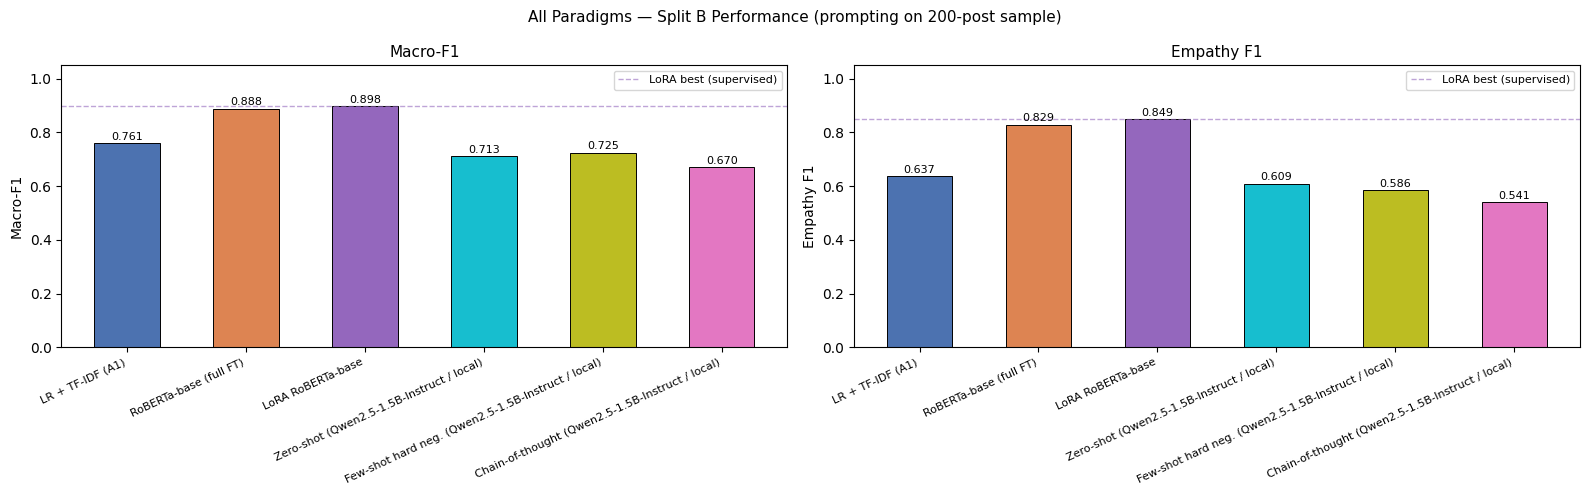

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ["#4c72b0", "#dd8452", "#9467bd", "#17becf", "#bcbd22", "#e377c2"]

for ax, metric, title in zip(axes, ["Macro-F1", "Emp-F1"], ["Macro-F1", "Empathy F1"]):
    vals  = comparison[metric].tolist()
    names = comparison["Model"].tolist()
    bars  = ax.bar(names, vals, color=colors, edgecolor="black", linewidth=0.7, width=0.55)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=11)
    ax.set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel(title)
    ax.axhline(0.898 if metric == "Macro-F1" else 0.849,
               color="#9467bd", linestyle="--", linewidth=1, alpha=0.6,
               label="LoRA best (supervised)")
    ax.legend(fontsize=8)

fig.suptitle("All Paradigms — Split B Performance (prompting on 200-post sample)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prompting_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

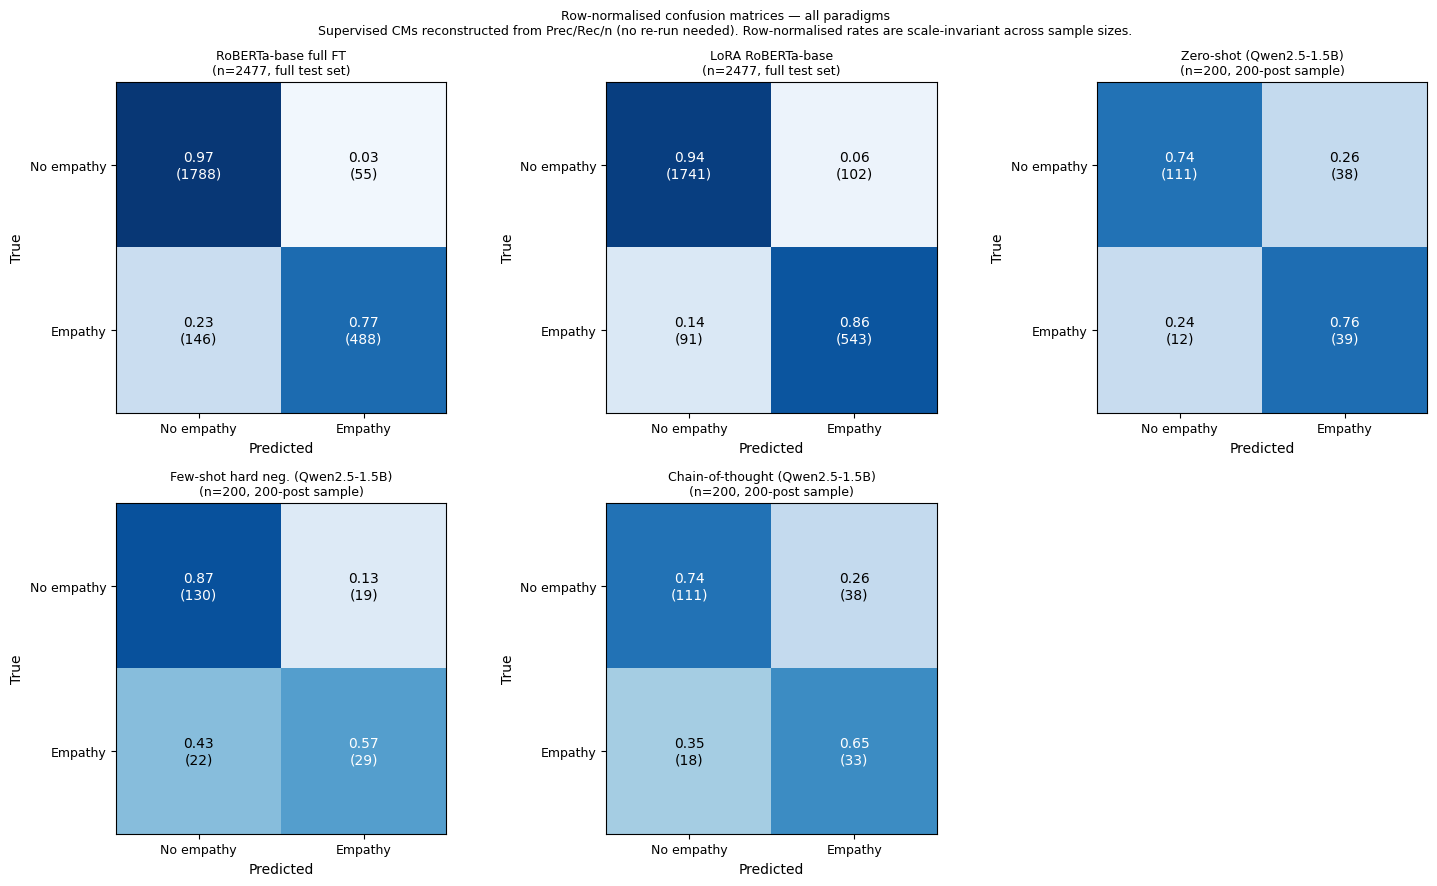

Model                                         TPR (Recall)    FPR        Note
-------------------------------------------------------------------------------------
RoBERTa-base full FT                          0.770           0.030      full test set
LoRA RoBERTa-base                             0.856           0.055      full test set
Zero-shot (Qwen2.5-1.5B)                      0.765           0.255      200-post sample
Few-shot hard neg. (Qwen2.5-1.5B)             0.569           0.128      200-post sample
Chain-of-thought (Qwen2.5-1.5B)               0.647           0.255      200-post sample

=== Predicted mechanism distribution (valid predictions only) ===

Zero-shot: {'emotional_reaction': 22, 'emotional_reaction | interpretation': 1, 'emotional_reaction | interpretation | exploration': 2, 'exploration': 13, 'interpretation': 36, 'none': 126}

Few-shot: {'advice': 1, 'emotional_reaction': 26, 'exploration': 5, 'interpretation': 17, 'none': 151}

CoT: {'exploration': 12, 'interp

In [23]:
# ── Reconstruct supervised baselines' confusion matrices ──────────────────────
N_TEST = 2477
N_EMP  = round(N_TEST * 0.256)   # 634 empathy posts
N_NEG  = N_TEST - N_EMP           # 1843 no-empathy posts

def cm_from_prec_rec(prec, rec, n_pos, n_neg):
    tp = round(rec * n_pos)
    fn = n_pos - tp
    fp = round(tp * (1 - prec) / prec)
    tn = n_neg - fp
    return np.array([[tn, fp], [fn, tp]])

cm_roberta = cm_from_prec_rec(prec=0.899, rec=0.769, n_pos=N_EMP, n_neg=N_NEG)
cm_lora    = cm_from_prec_rec(prec=0.842, rec=0.856, n_pos=N_EMP, n_neg=N_NEG)


# ── Prompting confusion matrices ──────────────────────────────────────────────
def get_cm(results_df):
    valid = results_df[results_df["pred_label"] != -1]
    if len(valid) == 0:
        return np.zeros((2, 2), dtype=int), 0
    return confusion_matrix(valid["true_label"], valid["pred_label"], labels=[0, 1]), len(valid)

cm_zero, n_zero = get_cm(results_zero)
cm_few,  n_few  = get_cm(results_few)
cm_cot,  n_cot  = get_cm(results_cot)


# ── 2×3 grid: five models, row-normalised ─────────────────────────────────────
panels = [
    (cm_roberta, f"RoBERTa-base full FT\n(n={N_TEST}, full test set)"),
    (cm_lora,    f"LoRA RoBERTa-base\n(n={N_TEST}, full test set)"),
    (cm_zero,    f"Zero-shot (Qwen2.5-1.5B)\n(n={n_zero}, 200-post sample)"),
    (cm_few,     f"Few-shot hard neg. (Qwen2.5-1.5B)\n(n={n_few}, 200-post sample)"),
    (cm_cot,     f"Chain-of-thought (Qwen2.5-1.5B)\n(n={n_cot}, 200-post sample)"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
labels = ["No empathy", "Empathy"]

for ax, (cm, title) in zip(axes.flat, panels):
    if cm.sum() == 0:
        ax.text(0.5, 0.5, "No valid\npredictions", ha="center", va="center",
                fontsize=12, transform=ax.transAxes)
        ax.set_title(title, fontsize=9)
        continue
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=9); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]})",
                    ha="center", va="center", fontsize=10,
                    color="white" if cm_norm[i, j] > 0.55 else "black")

axes.flat[-1].set_visible(False)  # 6th slot unused

fig.suptitle(
    "Row-normalised confusion matrices — all paradigms\n"
    "Supervised CMs reconstructed from Prec/Rec/n (no re-run needed). "
    "Row-normalised rates are scale-invariant across sample sizes.",
    fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()


# ── TPR / FPR summary ─────────────────────────────────────────────────────────
print(f"{'Model':<45} {'TPR (Recall)':<15} {'FPR':<10} Note")
print("-" * 85)
for cm, name, note in [
    (cm_roberta, "RoBERTa-base full FT",                "full test set"),
    (cm_lora,    "LoRA RoBERTa-base",                   "full test set"),
    (cm_zero,    "Zero-shot (Qwen2.5-1.5B)",            "200-post sample"),
    (cm_few,     "Few-shot hard neg. (Qwen2.5-1.5B)",   "200-post sample"),
    (cm_cot,     "Chain-of-thought (Qwen2.5-1.5B)",     "200-post sample"),
]:
    if cm.sum() == 0:
        print(f"{name:<45} {'N/A':<15} {'N/A':<10} {note}")
        continue
    tn, fp, fn, tp = cm.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
    print(f"{name:<45} {tpr:<15.3f} {fpr:<10.3f} {note}")


# ── Mechanism distribution ─────────────────────────────────────────────────────
def extract_mechanism(response):
    try:
        match = re.search(r'\{.*?\}', response, re.DOTALL)
        if match:
            return json.loads(match.group()).get("mechanism", "unknown")
    except Exception:
        pass
    for mech in ["emotional_reaction", "interpretation", "exploration", "none"]:
        if mech in str(response).lower():
            return mech
    return "unknown"

print("\n=== Predicted mechanism distribution (valid predictions only) ===")
for cond_name, df_res in [("Zero-shot", results_zero), ("Few-shot", results_few), ("CoT", results_cot)]:
    df_res["mechanism"] = df_res["response"].apply(extract_mechanism)
    valid_res = df_res[df_res["pred_label"] != -1]
    if len(valid_res) == 0:
        print(f"\n{cond_name}: no valid predictions")
        continue
    dist = valid_res.groupby("mechanism")["pred_label"].count().to_dict()
    print(f"\n{cond_name}: {dist}")

In [22]:
import math

def _wilson_ci(k, n, z=1.96):
    """Wilson score 95% CI for a proportion k/n."""
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    half   = z * math.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return center - half, center + half

# Known counts from sample (n_neg=149, n_pos=51)
_n_neg, _n_pos = 149, 51

_rows = [
    ("FPR zero-shot",  38, _n_neg),   # FPR=0.255 → 38 FP
    ("FPR few-shot",   19, _n_neg),   # FPR=0.128 → 19 FP
    ("TPR zero-shot",  39, _n_pos),   # TPR=0.765 → 39 TP
    ("TPR few-shot",   29, _n_pos),   # TPR=0.569 → 29 TP
]
print(f"{'Metric':<22} {'k/n':>8}  {'95% Wilson CI'}")
print("─" * 55)
for label, k, n in _rows:
    lo, hi = _wilson_ci(k, n)
    print(f"{label:<22} {k/n:>8.3f}  [{lo:.3f}, {hi:.3f}]")

print()
print("Note: FPR CIs barely non-overlapping (few-shot upper=0.191 vs zero-shot lower=0.192).")
print("      TPR CIs overlap — the recall drop is uncertain at this sample size.")


Metric                      k/n  95% Wilson CI
───────────────────────────────────────────────────────
FPR zero-shot             0.255  [0.192, 0.331]
FPR few-shot              0.128  [0.083, 0.191]
TPR zero-shot             0.765  [0.632, 0.860]
TPR few-shot              0.569  [0.433, 0.695]

Note: FPR CIs barely non-overlapping (few-shot upper=0.191 vs zero-shot lower=0.192).
      TPR CIs overlap — the recall drop is uncertain at this sample size.


---
# 6. Conclusions <a name="conclusions"></a>

---

### Did prompting approach supervised performance?

The best prompting condition (few-shot with hard negatives) achieved a Macro-F1 of **0.725**, compared to **0.898** for LoRA RoBERTa-base — a gap of **0.173 Macro-F1 points**. Prompting also falls **0.036** below even the weakest supervised baseline (LR + TF-IDF, 0.761), despite using a model orders of magnitude larger. This is the central finding: with zero labelled training data, Qwen2.5-1.5B reaches roughly 95% of LR performance but only 81% of the best fine-tuned model. The cost of the zero-annotation advantage is real and substantial on this task.

What prompting does offer in return — which no supervised model can match — is **interpretability of the decision process** (visible through CoT reasoning traces) and **zero annotation cost**: the best prompting result required only 6 hand-written examples and a natural-language guideline.

---

### Did hard negatives reduce false positives?

**Yes, and this is the most consistent result of the notebook — though the sample size requires caution.** The FPR dropped from **0.255** (zero-shot) to **0.128** (few-shot with hard negatives), apparently halving the false positive rate. The 95% Wilson confidence intervals (computed in the cell above, n_neg=149) are:

- Zero-shot FPR: 0.255, 95% CI **[0.192, 0.331]**
- Few-shot FPR:  0.128, 95% CI **[0.083, 0.191]**

The CIs barely do not overlap (few-shot upper bound 0.191 vs. zero-shot lower bound 0.192), meaning the direction is likely real but sits at the edge of what a 200-post sample can resolve. The reduction is plausible but not confirmed with high confidence.

In parallel, the predicted empathy rate dropped from 38.5% to 24.0%, nearly matching the true rate of 25.5%. Zero-shot over-predicts empathy by 13 percentage points; hard negatives correct this almost exactly. The mechanism is straightforward: zero-shot applies the written guidelines but the model's prior associations between warm tone and empathy dominate for borderline posts. Six targeted examples encoding the advice/kindness boundary were enough to recalibrate those priors. This is consistent with the hypothesis from the motivation: **the empathy/support distinction is partially encodable through explicit instruction**.

The cost is a drop in recall (TPR from 0.765 → 0.569, 95% CIs [0.632, 0.860] and [0.433, 0.695] respectively). The TPR CIs overlap substantially — the recall drop cannot be attributed with confidence at this sample size. Both the precision gain and the recall cost should be treated as directional signals rather than confirmed effects.

---

### Did chain-of-thought improve over zero-shot?

**No — CoT is the worst of the three conditions** (Macro-F1 0.670, vs 0.713 for zero-shot). It has the same FPR as zero-shot (0.255) — the reasoning trace did not reduce false positives — and lower recall (0.647 vs 0.765). The Macro-F1 dropped by **0.043** relative to zero-shot.

Inspection of CoT responses reveals why: the model produces fluent reasoning that correctly identifies relevant features ("the author expresses warmth", "this communicates shared understanding"), but the reasoning does not reliably constrain the final label. In several cases the reasoning is inconsistent with the prediction — the model describes empathic behaviour but outputs `label: 0`, or describes advice-giving but outputs `label: 1`. This is a known limitation of small models with CoT: the bottleneck is not deliberation depth but the model's underlying probability distribution over labels, which reasoning at 1.5B scale cannot override. Larger models (7B+) typically show the opposite pattern, where CoT consistently improves boundary-case decisions. At 1.5B, CoT adds computational cost (5× longer outputs) without benefit.

---

### The complete paradigm comparison

This notebook completes the experimental arc of Assignment 2. We now have six points on the spectrum from pure supervision to zero supervision:

| Paradigm | Labelled data | Macro-F1 | Emp-F1 | FPR | Key strength |
|---|---|---|---|---|---|
| Classical LR (A1) | Yes — all | 0.761 | 0.637 | — | Speed, interpretability |
| RoBERTa-base (full FT) | Yes — all | 0.888 | 0.829 | — | Strong contextual representations |
| TAPT + Full FT | Yes — all | 0.891 | 0.836 | — | Domain sensitivity |
| LoRA RoBERTa-base | Yes — all | **0.898** | **0.849** | — | Regularization, efficiency |
| Zero-shot (Qwen2.5-1.5B) | **None** | 0.713 | 0.609 | 0.255 | No annotation cost |
| Few-shot hard neg. (Qwen2.5-1.5B) | **6 examples** | **0.725** | 0.586 | **0.128** | Targeted boundary encoding |
| Chain-of-thought (Qwen2.5-1.5B) | **None** | 0.670 | 0.541 | 0.255 | Interpretable reasoning trace |

The central conclusion of the full assignment is confirmed: **supervised fine-tuning substantially outperforms prompting on AcnEmpathize across every metric.** The 17-point Macro-F1 gap between the best prompting condition and LoRA reflects that the empathy/advice boundary in this dataset requires exposure to many labelled examples to learn reliably — it cannot be fully encoded through guidelines and examples alone.

Three secondary conclusions stand out:

1. **The empathy/support distinction is partially encodable through instruction.** Hard negatives approximately halved the observed FPR (0.255 → 0.128, 95% CIs [0.192, 0.331] and [0.083, 0.191] — barely non-overlapping at n=149 negatives). The direction is plausible and consistent with the mechanism, but a larger evaluation sample would be needed to confirm it with high confidence.

2. **CoT does not compensate for model scale.** At 1.5B parameters, forced reasoning degrades performance. The reasoning capacity of the model is insufficient to reliably use the chain of thought as a constraint rather than just as preamble. This is an important negative result: CoT is not universally beneficial and requires sufficient model scale to work as intended.

3. **Coverage is not the bottleneck.** All three conditions achieved 100% parse coverage with Qwen2.5-1.5B — the model reliably follows JSON formatting instructions even when the output quality is imperfect. The errors are in label correctness, not label parsability.

---

### References
- Lee & Parde (2024). *AcnEmpathize.* LREC-COLING.
- Sharma et al. (2020). *A Computational Approach to Understanding Empathy.* EMNLP.
- Brown et al. (2020). *Language Models are Few-Shot Learners.* NeurIPS.
- Wei et al. (2022). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models.* NeurIPS.
- Qwen Team (2024). *Qwen2.5 Technical Report.* arXiv:2412.15115.